# ============================================================
# EXTENDED ISOLATION FOREST — PREPROCESADO FFT
# Features: espectro dB normalizado (0–1kHz) por señal
# 8 señales × 1001 bins = 8008 features por ventana
# Umbral: media + 3*std (paper)
# Agregación por experimento (mediana de 100 ventanas)
# ============================================================

In [13]:
# ============================================================
# 0. INSTALACIÓN
# ============================================================

!pip install h2o optuna optuna-dashboard plotly seaborn

In [14]:
# ============================================================
# 1. IMPORTS
# ============================================================

import h2o
from h2o.estimators import H2OExtendedIsolationForestEstimator
import optuna
from optuna.trial import TrialState
import optuna.visualization as vis
import numpy as np
import pandas as pd
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "browser"

In [15]:
# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

RUTA_FEATURES   = "features_fft"          # <-- carpeta nueva con preprocesado FFT
CSV_INDEX       = "Motor_DB/index/master_index.csv"
RUTA_RESULTADOS = "resultados_fft"
os.makedirs(RUTA_RESULTADOS, exist_ok=True)

N_TRIALS          = 500
SEED              = 42
VENTANAS_POR_EXP  = 100   # 100 segundos a 20kHz, ventanas de 1s

# El extension_level máximo de EIF = n_features - 1
# Se calcula dinámicamente tras leer las columnas (ver celda siguiente)

VELOCIDADES_ESTABLES = {"S1500", "S1200", "S900"}  # regímenes estables (excluye STrap, SSteps, SStart y S20)


In [16]:
# ============================================================
# 3. LEER COLUMNAS Y CALCULAR EXT_MAX
# ============================================================

cols_todas      = pd.read_csv(os.path.join(RUTA_FEATURES, "train", "sano_train.csv"), nrows=0).columns.tolist()
cols_electricas = [c for c in cols_todas if c.startswith(("u_bin", "v_bin", "w_bin"))]
cols_vibracion  = [c for c in cols_todas if c not in cols_electricas]

N_FEATURES   = len(cols_todas)       # 8008
EXT_MAX      = N_FEATURES - 1        # 8007

print(f"Total features   : {N_FEATURES}")
print(f"  Eléctricas     : {len(cols_electricas)}  (u, v, w × 1001 bins)")
print(f"  Vibración      : {len(cols_vibracion)}  (5 señales × 1001 bins)")
print(f"EXT_MAX          : {EXT_MAX}")

# NOTA IMPORTANTE sobre extension_level:
# El paper recomienda usar extension_level = n_features - 1 para EIF completo.
# Con 8008 features ese valor es muy alto y puede ser lento.
# Optuna explorará el rango [0, EXT_MAX] pero en la práctica
# valores entre 0 y 50 suelen dar buenos resultados con alta dimensionalidad.
# Si los trials son lentos, reduce EXT_MAX a 100 manualmente aquí.
EXT_MAX_BUSQUEDA = min(EXT_MAX, 100)  # limita la búsqueda Optuna a [0, 100]
print(f"EXT_MAX búsqueda : {EXT_MAX_BUSQUEDA}  (rango Optuna)")

Total features   : 8008
  Eléctricas     : 3003  (u, v, w × 1001 bins)
  Vibración      : 5005  (5 señales × 1001 bins)
EXT_MAX          : 8007
EXT_MAX búsqueda : 100  (rango Optuna)


In [5]:
# ============================================================
# 4. INICIALIZAR H2O
# ============================================================

# Con 8008 features y 100 ventanas/experimento los frames son grandes.
# Ajusta max_mem_size según tu RAM disponible.
h2o.init(
    nthreads    = -1,
    max_mem_size = "12G"
)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "26.0.1" 2026-04-21; OpenJDK Runtime Environment (build 26.0.1); OpenJDK 64-Bit Server VM (build 26.0.1, mixed mode, sharing)
  Starting server from /home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmphqkescni
  JVM stdout: /tmp/tmphqkescni/h2o_arielingm_started_from_python.out
  JVM stderr: /tmp/tmphqkescni/h2o_arielingm_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Madrid
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,1 month and 5 days
H2O_cluster_name:,H2O_from_python_arielingm_7zb53v
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,11.98 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [6]:
# ============================================================
# 5. CARGAR DATOS
# ============================================================

print("Cargando datos...\n")

index = pd.read_csv(CSV_INDEX)

# Filtrar transitorios — mismo criterio que el preprocesado FFT
index = index[index["Velocidad"].astype(str).isin(VELOCIDADES_ESTABLES)].reset_index(drop=True)
print(f"Index tras filtro: {len(index)} experimentos (transitorios excluidos)\n")

train     = h2o.import_file(os.path.join(RUTA_FEATURES, "train", "sano_train.csv"))
val       = h2o.import_file(os.path.join(RUTA_FEATURES, "val",   "sano.csv"))
test_sano = h2o.import_file(os.path.join(RUTA_FEATURES, "test",  "sano.csv"))

carpeta_test  = os.path.join(RUTA_FEATURES, "test")
fallos_frames = {}
for archivo in sorted(os.listdir(carpeta_test)):
    if archivo.endswith(".csv") and archivo != "sano.csv":
        nombre = archivo.replace(".csv", "")
        fallos_frames[nombre] = h2o.import_file(os.path.join(carpeta_test, archivo))

print(f"Train     : {train.shape[0]} ventanas  ({train.shape[0] // VENTANAS_POR_EXP} experimentos)")
print(f"Val sano  : {val.shape[0]} ventanas  ({val.shape[0] // VENTANAS_POR_EXP} experimentos)")
print(f"Test sano : {test_sano.shape[0]} ventanas  ({test_sano.shape[0] // VENTANAS_POR_EXP} experimentos)")
print(f"Grupos de fallo: {len(fallos_frames)}")

VELOCIDADES_ESTABLES = {"S1500", "S1200", "S900"}  # regímenes estables (excluye STrap, SSteps, SStart y S20)


Cargando datos...

Index tras filtro: 169 experimentos (transitorios excluidos)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |███████████████████████████████████████████████

In [7]:
# ============================================================
# 6. FUNCIÓN DE AGREGACIÓN POR EXPERIMENTO
# ============================================================

def agregar_por_experimento(scores_array, ventanas_por_exp):
    """
    Divide los scores en bloques de ventanas_por_exp ventanas
    y devuelve la mediana de cada bloque (= 1 score por experimento).
    """
    medianas = []
    for i in range(0, len(scores_array), ventanas_por_exp):
        grupo = scores_array[i : i + ventanas_por_exp]
        if len(grupo) > 0:
            medianas.append(np.median(grupo))
    return np.array(medianas)

def agregar_variable(scores_array, n_archivos):
    """
    Para grupos con distinto nº de ventanas: divide equitativamente
    el total entre n_archivos.
    """
    ventanas_por_exp = len(scores_array) // n_archivos
    return agregar_por_experimento(scores_array, ventanas_por_exp)

In [8]:
# ============================================================
# 7. FUNCIÓN OBJETIVO OPTUNA
# ============================================================

def objective(trial):

    ntrees          = trial.suggest_int("ntrees",          100, 800)
    sample_size     = trial.suggest_int("sample_size",     256, 512, step=64)
    extension_level = trial.suggest_int("extension_level", 0,   EXT_MAX_BUSQUEDA)

    model = H2OExtendedIsolationForestEstimator(
        ntrees          = ntrees,
        sample_size     = sample_size,
        extension_level = extension_level,
        seed            = SEED
    )
    try:
        model.train(training_frame=train)
    except Exception as e:
        print(f"  Trial fallido: ntrees={ntrees}, sample_size={sample_size} → {e}")
        raise optuna.exceptions.TrialPruned()

    s_train = model.predict(train)["anomaly_score"].as_data_frame().values.flatten()
    s_val   = model.predict(val)["anomaly_score"].as_data_frame().values.flatten()

    med_train = agregar_por_experimento(s_train, VENTANAS_POR_EXP)
    med_val   = agregar_por_experimento(s_val,   VENTANAS_POR_EXP)
    todos     = np.concatenate([med_train, med_val])

    media  = np.mean(todos)
    std    = np.std(todos)
    umbral = media + 3 * std

    trial.set_user_attr("media",  round(float(media),  6))
    trial.set_user_attr("std",    round(float(std),    6))
    trial.set_user_attr("umbral", round(float(umbral), 6))

    return umbral   # minimizar el umbral → modelo más conservador con sanos

In [9]:
h2o.cluster().show_status()   # verificar que H2O sigue vivo antes de empezar

H2O_cluster_uptime:,1 min 08 secs
H2O_cluster_timezone:,Europe/Madrid
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,1 month and 5 days
H2O_cluster_name:,H2O_from_python_arielingm_7zb53v
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8.35 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [10]:
# ============================================================
# 8. OPTIMIZACIÓN OPTUNA
# ============================================================

print("\n" + "="*60)
print(f"Iniciando optimización: {N_TRIALS} trials")
print(f"Features por ventana : {N_FEATURES}")
print("="*60 + "\n")

sampler = optuna.samplers.TPESampler(seed=SEED)
study   = optuna.create_study(
    direction      = "minimize",
    sampler        = sampler,
    storage        = f"sqlite:///{RUTA_RESULTADOS}/optuna_eif_fft.db",
    study_name     = "EIF_motores_fft_8008features",
    load_if_exists = True
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)


Iniciando optimización: 500 trials
Features por ventana : 8008



[I 2026-06-27 19:59:44,113] Using an existing study with name 'EIF_motores_fft_8008features' instead of creating a new one.
  0%|          | 0/500 [00:00<?, ?it/s]

extendedisolationforest Model Build progress: |█████████████████████████████████

Best trial: 52. Best value: 0.465825:   0%|          | 1/500 [08:05<67:15:21, 485.21s/it]

 (failed)  98%
  Trial fallido: ntrees=146, sample_size=448 → Job with key $03017f00000132d4ffffffff$_9c7a26edfee3e1594c9a0e9a93714ee0 failed with an exception: java.lang.OutOfMemoryError: Java heap space
stacktrace: 
java.lang.OutOfMemoryError: Java heap space
	at hex.tree.isoforextended.isolationtree.IsolationTree.extendedIsolationForestSplit(IsolationTree.java:225)
	at hex.tree.isoforextended.isolationtree.IsolationTree.buildTree(IsolationTree.java:77)
	at hex.tree.isoforextended.ExtendedIsolationForest$ExtendedIsolationForestDriver.buildIsolationTreeEnsemble(ExtendedIsolationForest.java:178)
	at hex.tree.isoforextended.ExtendedIsolationForest$ExtendedIsolationForestDriver.computeImpl(ExtendedIsolationForest.java:150)
	at hex.ModelBuilder$Driver.compute2(ModelBuilder.java:253)
	at water.H2O$H2OCountedCompleter.compute(H2O.java:1704)
	at jsr166y.CountedCompleter.exec(CountedCompleter.java:468)
	at jsr166y.ForkJoinTask.doExec(ForkJoinTask.java:263)
	at jsr166y.ForkJoinPool$WorkQueue.r

...

 (failed)
  Trial fallido: ntrees=101, sample_size=448 → Job with key $03017f00000132d4ffffffff$_b16a6af61ea75022163d3f20e9524a78 failed with an exception: water.exceptions.H2OModelBuilderIllegalArgumentException: Illegal argument(s) for ExtendedIsolationForest model: ExtendedIsolationForest_model_python_1782583113298_498.  Details: ERRR on field: _train: Extended Isolation Forest computation won't fit in the driver node's memory (3.84 GB > 3.79 GB) - try reducing the number of columns and/or the number of trees and/or the sample_size parameter. You can disable memory check by setting the attribute sys.ai.h2o.debug.noMemoryCheck.

stacktrace: 
water.exceptions.H2OModelBuilderIllegalArgumentException: Illegal argument(s) for ExtendedIsolationForest model: ExtendedIsolationForest_model_python_1782583113298_498.  Details: ERRR on field: _train: Extended Isolation Forest computation won't fit in the driver node's memory (3.84 GB > 3.79 GB) - try reducing the number of columns and/or the nu

Best trial: 52. Best value: 0.465825: 100%|█████████▉| 499/500 [12:07<00:00,  1.34it/s]

 (failed)
  Trial fallido: ntrees=752, sample_size=512 → Job with key $03017f00000132d4ffffffff$_aa6c922bf4c2712fea63659eebf44d1e failed with an exception: water.exceptions.H2OModelBuilderIllegalArgumentException: Illegal argument(s) for ExtendedIsolationForest model: ExtendedIsolationForest_model_python_1782583113298_499.  Details: ERRR on field: _train: Extended Isolation Forest computation won't fit in the driver node's memory (57.33 GB > 3.79 GB) - try reducing the number of columns and/or the number of trees and/or the sample_size parameter. You can disable memory check by setting the attribute sys.ai.h2o.debug.noMemoryCheck.

stacktrace: 
water.exceptions.H2OModelBuilderIllegalArgumentException: Illegal argument(s) for ExtendedIsolationForest model: ExtendedIsolationForest_model_python_1782583113298_499.  Details: ERRR on field: _train: Extended Isolation Forest computation won't fit in the driver node's memory (57.33 GB > 3.79 GB) - try reducing the number of columns and/or the 

Best trial: 52. Best value: 0.465825: 100%|██████████| 500/500 [12:07<00:00,  1.45s/it]

 (failed)
  Trial fallido: ntrees=347, sample_size=384 → Job with key $03017f00000132d4ffffffff$_825cbd43e620bbad1f63bfb3d264a4a failed with an exception: water.exceptions.H2OModelBuilderIllegalArgumentException: Illegal argument(s) for ExtendedIsolationForest model: ExtendedIsolationForest_model_python_1782583113298_500.  Details: ERRR on field: _train: Extended Isolation Forest computation won't fit in the driver node's memory (13.20 GB > 3.79 GB) - try reducing the number of columns and/or the number of trees and/or the sample_size parameter. You can disable memory check by setting the attribute sys.ai.h2o.debug.noMemoryCheck.

stacktrace: 
water.exceptions.H2OModelBuilderIllegalArgumentException: Illegal argument(s) for ExtendedIsolationForest model: ExtendedIsolationForest_model_python_1782583113298_500.  Details: ERRR on field: _train: Extended Isolation Forest computation won't fit in the driver node's memory (13.20 GB > 3.79 GB) - try reducing the number of columns and/or the n

In [11]:
# ============================================================
# 9. RESULTADOS OPTUNA
# ============================================================

complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

print("\n" + "="*60)
print("RESULTADOS OPTUNA")
print("="*60)
print(f"  Trials completados : {len(complete_trials)}")

best = study.best_trial
print(f"\n  Mejor umbral       : {best.value:.6f}")
print(f"  media              : {best.user_attrs['media']:.6f}")
print(f"  std                : {best.user_attrs['std']:.6f}")
print(f"\n  Mejores hiperparámetros:")
for k, v in best.params.items():
    print(f"    {k}: {v}")

with open(os.path.join(RUTA_RESULTADOS, "mejores_hiperparametros.json"), "w") as f:
    json.dump(best.params, f, indent=2)


RESULTADOS OPTUNA
  Trials completados : 1

  Mejor umbral       : 0.465825
  media              : 0.415260
  std                : 0.016855

  Mejores hiperparámetros:
    ntrees: 109
    sample_size: 256
    extension_level: 59


In [17]:
# ============================================================
# 10. MODELO FINAL
# ============================================================

# Reiniciar H2O para liberar memoria antes del entrenamiento final
h2o.cluster().shutdown(prompt=False)
import time
time.sleep(5)

h2o.init(nthreads=-1, max_mem_size="16G")

# Recargar datos
train     = h2o.import_file(os.path.join(RUTA_FEATURES, "train", "sano_train.csv"))
val       = h2o.import_file(os.path.join(RUTA_FEATURES, "val",   "sano.csv"))
test_sano = h2o.import_file(os.path.join(RUTA_FEATURES, "test",  "sano.csv"))

fallos_frames = {}
for archivo in sorted(os.listdir(carpeta_test)):
    if archivo.endswith(".csv") and archivo != "sano.csv":
        nombre = archivo.replace(".csv", "")
        fallos_frames[nombre] = h2o.import_file(os.path.join(carpeta_test, archivo))

print("\n" + "="*60)
print("ENTRENANDO MODELO FINAL")
print("="*60)

# Recargar best desde Optuna por si se reinició el kernel
study = optuna.load_study(
    study_name = "EIF_motores_fft_8008features",
    storage    = f"sqlite:///{RUTA_RESULTADOS}/optuna_eif_fft.db"
)
best = study.best_trial

modelo_final = H2OExtendedIsolationForestEstimator(
    ntrees          = best.params["ntrees"],
    sample_size     = best.params["sample_size"],
    extension_level = best.params["extension_level"],
    seed            = SEED
)
modelo_final.train(training_frame=train)

# Calcular umbral final con train + val
s_train_f = modelo_final.predict(train)["anomaly_score"].as_data_frame().values.flatten()
s_val_f   = modelo_final.predict(val)["anomaly_score"].as_data_frame().values.flatten()

med_train_f = agregar_por_experimento(s_train_f, VENTANAS_POR_EXP)
med_val_f   = agregar_por_experimento(s_val_f,   VENTANAS_POR_EXP)
med_sanos   = np.concatenate([med_train_f, med_val_f])

media_sanos = np.mean(med_sanos)
std_sanos   = np.std(med_sanos)
umbral      = media_sanos + 3 * std_sanos

print(f"\n  Umbral final (media + 3·std) : {umbral:.6f}")
print(f"  Media sanos                  : {media_sanos:.6f}")
print(f"  Std sanos                    : {std_sanos:.6f}")

# Guardar umbral
with open(os.path.join(RUTA_RESULTADOS, "umbral.json"), "w") as f:
    json.dump({"umbral": umbral, "media": media_sanos, "std": std_sanos}, f, indent=2)

VELOCIDADES_ESTABLES = {"S1500", "S1200", "S900"}  # regímenes estables (excluye STrap, SSteps, SStart y S20)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "26.0.1" 2026-04-21; OpenJDK Runtime Environment (build 26.0.1); OpenJDK 64-Bit Server VM (build 26.0.1, mixed mode, sharing)
  Starting server from /home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpqp846lo6
  JVM stdout: /tmp/tmpqp846lo6/h2o_arielingm_started_from_python.out
  JVM stderr: /tmp/tmpqp846lo6/h2o_arielingm_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Madrid
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,1 month and 5 days
H2O_cluster_name:,H2O_from_python_arielingm_jfiknk
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.98 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |█████████████████████████████████

/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%

  Umbral final (media + 3·std) : 0.465825
  Media sanos                  : 0.415260
  Std sanos                    : 0.016855


In [18]:
# ============================================================
# 11. EVALUACIÓN POR EXPERIMENTO
# ============================================================

print("\n" + "="*60)
print("EVALUACIÓN POR EXPERIMENTO")
print("="*60)

resultados    = []
datos_boxplot = []

def evaluar_grupo(nombre, scores, n_archivos, es_fallo=True):
    medianas   = agregar_variable(scores, n_archivos)
    detectados = np.sum(medianas > umbral)
    total      = len(medianas)
    deteccion  = detectados / total * 100

    for m in medianas:
        datos_boxplot.append({"grupo": nombre, "mediana": m, "es_fallo": es_fallo})

    return {
        "grupo":          nombre,
        "n_experimentos": total,
        "detectados":     int(detectados),
        "deteccion_%":    round(deteccion, 1),
        "mediana_media":  round(float(np.mean(medianas)), 6),
        "mediana_max":    round(float(np.max(medianas)),  6),
    }

# Sano test
s_sano_test = modelo_final.predict(test_sano)["anomaly_score"].as_data_frame().values.flatten()
n_sano_test = len(index[(index["Split"] == "test") & (index["Maquina"] == "h")])
res_sano    = evaluar_grupo("sano_test", s_sano_test, n_sano_test, es_fallo=False)
resultados.append(res_sano)
print(f"\n  sano_test → {res_sano['detectados']}/{res_sano['n_experimentos']} "
      f"detectados como anomalía ({res_sano['deteccion_%']}%)  ← idealmente 0%")

# Fallos
print()
for nombre, frame in sorted(fallos_frames.items()):
    s_f    = modelo_final.predict(frame)["anomaly_score"].as_data_frame().values.flatten()
    n_arch = len(index[(index["Split"] == "test") & (index["Fallo"] == nombre)])
    res    = evaluar_grupo(nombre, s_f, n_arch, es_fallo=True)
    resultados.append(res)
    print(f"  {nombre:<55} "
          f"{res['detectados']:>2}/{res['n_experimentos']:>2}  "
          f"({res['deteccion_%']:>5.1f}%)")

# Añadir train y val al boxplot
for nombre, scores in [("sano_train", s_train_f), ("sano_val", s_val_f)]:
    for m in agregar_por_experimento(scores, VENTANAS_POR_EXP):
        datos_boxplot.append({"grupo": nombre, "mediana": m, "es_fallo": False})

# Guardar resultados
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv(os.path.join(RUTA_RESULTADOS, "resultados_por_experimento.csv"), index=False)
print(f"\nGuardado: {RUTA_RESULTADOS}/resultados_por_experimento.csv")


EVALUACIÓN POR EXPERIMENTO
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%

  sano_test → 0/7 detectados como anomalía (0.0%)  ← idealmente 0%

extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
  fallo_barra_rota_1_DTC_S1200                             0/ 4  (  0.0%)
extendedisolationforest prediction progress: |

/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%


/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


  fallo_barra_rota_1_DTC_S1500                             0/ 4  (  0.0%)
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
  fallo_barra_rota_1_DTC_S900                              0/ 4  (  0.0%)
extendedisolationforest prediction progress: |

...

/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_rodamiento_groove_scalar_S1500                     0/ 5  (  0.0%)
extendedisolationforest prediction progress: |

/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_rodamiento_groove_scalar_S900                      0/ 3  (  0.0%)

Guardado: resultados_fft/resultados_por_experimento.csv


/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


/tmp/ipykernel_299511/3152437892.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


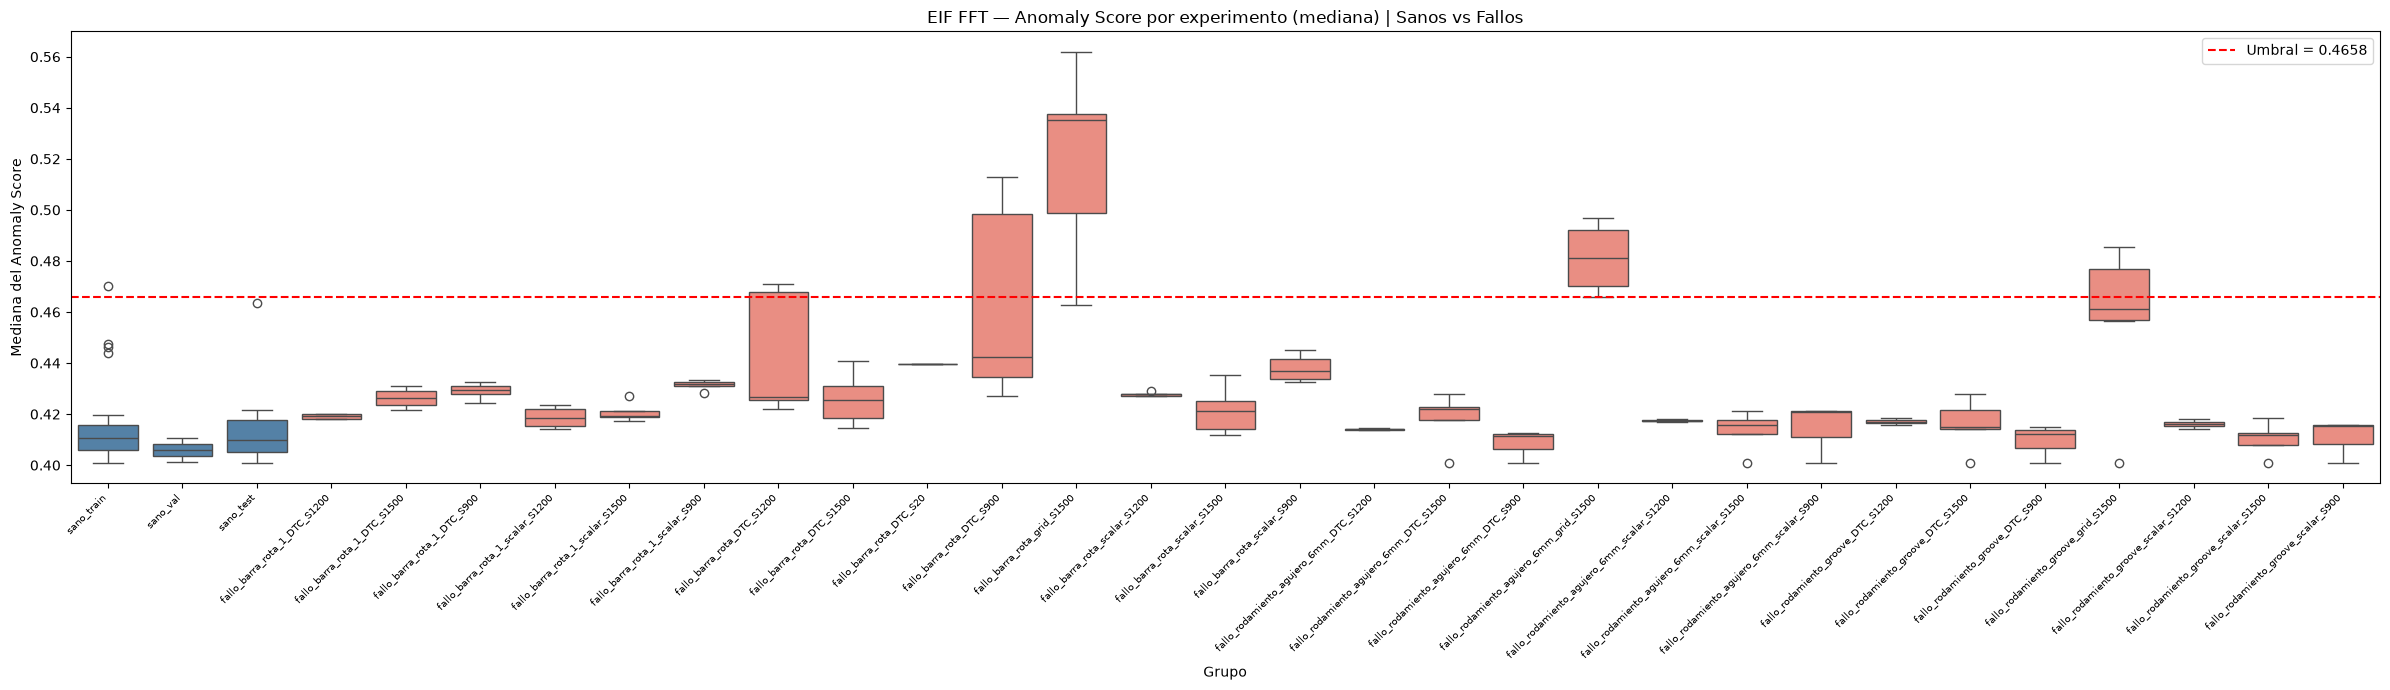

In [24]:
# ============================================================
# 12. BOXPLOT ESTILO PAPER
# ============================================================

df_box = pd.DataFrame(datos_boxplot)

grupos_sanos  = ["sano_train", "sano_val", "sano_test"]
grupos_fallos = sorted([n for n in df_box["grupo"].unique() if n not in grupos_sanos])
orden         = grupos_sanos + grupos_fallos
colores       = {g: "steelblue" if g in grupos_sanos else "salmon" for g in orden}

plt.figure(figsize=(24, 7))
sns.boxplot(
    data    = df_box[df_box["grupo"].isin(orden)],
    x       = "grupo",
    y       = "mediana",
    order   = orden,
    palette = colores
)
plt.axhline(y=umbral, color="red", linestyle="--", linewidth=1.5,
            label=f"Umbral = {umbral:.4f}")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.title("EIF FFT — Anomaly Score por experimento (mediana) | Sanos vs Fallos")
plt.xlabel("Grupo")
plt.ylabel("Mediana del Anomaly Score")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RUTA_RESULTADOS, "boxplot_resultados_fft.png"), dpi=150)
plt.show()

In [ ]:
# ============================================================
# 13. GRÁFICAS OPTUNA
# ============================================================

print("\nGenerando gráficas Optuna...")

fig1 = vis.plot_optimization_history(study)
fig1.update_layout(title="Evolución del umbral por trial")
fig1.write_html(os.path.join(RUTA_RESULTADOS, "optuna_historia.html"))
fig1.show()

fig2 = vis.plot_param_importances(study)
fig2.update_layout(title="Importancia de hiperparámetros")
fig2.write_html(os.path.join(RUTA_RESULTADOS, "optuna_importancia.html"))
fig2.show()

fig3 = vis.plot_parallel_coordinate(study)
fig3.update_layout(title="Coordenadas paralelas")
fig3.write_html(os.path.join(RUTA_RESULTADOS, "optuna_coordenadas.html"))
fig3.show()

fig4 = vis.plot_contour(study, params=["ntrees", "extension_level"])
fig4.update_layout(title="Contour: ntrees vs extension_level")
fig4.write_html(os.path.join(RUTA_RESULTADOS, "optuna_contour.html"))
fig4.show()

print("\n✅ Todo completado.")
print(f"Umbral final : {umbral:.6f}")
h2o.cluster().show_status()